# ES3A vs ES3B Benchmark
Confronto prestazionale tra versione base (es3A.c) e versione con memoization (es3B.c).

Il notebook compila i sorgenti, genera input validi e misura i tempi con mediana su piu run.

In [40]:
import subprocess
from pathlib import Path

root = Path('.').resolve()
src_a = root / 'es3A.c'
src_b = root / 'es3B.c'
exe_a = root / 'es3A'
exe_b = root / 'es3B'

if not src_a.exists() or not src_b.exists():
    raise FileNotFoundError('Servono es3A.c e es3B.c nella stessa cartella del notebook')

print('Compilazione in corso...')
subprocess.run(['gcc', '-O2', '-w', str(src_a), '-o', str(exe_a)], check=True)
subprocess.run(['gcc', '-O2', '-w', str(src_b), '-o', str(exe_b)], check=True)
print('Compilazione completata')

Compilazione in corso...
Compilazione completata


In [41]:
import random
import time
import statistics

rng = random.Random(42)

def gen_safe_instance(T, N):
    # Family semplice e sempre fattibile: tutte le pause durano 1 minuto.
    pauses = [1] * N
    return f'{T} {N}\n' + ' '.join(map(str, pauses)) + '\n'

def run_once(exe_path, input_data):
    t0 = time.perf_counter()
    p = subprocess.Popen(
        [str(exe_path)],
        stdin=subprocess.PIPE,
        stdout=subprocess.DEVNULL,
        stderr=subprocess.DEVNULL,
        text=True
    )
    p.communicate(input_data)
    return time.perf_counter() - t0

def run_and_capture(exe_path, input_data):
    p = subprocess.Popen(
        [str(exe_path)],
        stdin=subprocess.PIPE,
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE,
        text=True
    )
    out, _ = p.communicate(input_data)
    return out.strip()

def parse_instance(input_data):
    lines = [ln.strip() for ln in input_data.strip().splitlines() if ln.strip()]
    T, N = map(int, lines[0].split())
    pauses = list(map(int, lines[1].split()))
    return T, N, pauses

def validate_solution(input_data, output_data):
    T, N, pauses = parse_instance(input_data)

    if output_data.lower().startswith('no possible sol'):
        return False

    toks = output_data.split()
    if len(toks) != N:
        return False
    try:
        starts = list(map(int, toks))
    except ValueError:
        return False

    for i in range(N):
        s = starts[i]
        k = pauses[i]
        if s < 0 or s + k > T:
            return False

    for t in range(T):
        in_pause = 0
        for i in range(N):
            if starts[i] <= t < starts[i] + pauses[i]:
                in_pause += 1
        if in_pause > 2:
            return False

    return True

def measure(exe_path, input_data, repeats=2, warmup=1):
    for _ in range(warmup):
        run_once(exe_path, input_data)
    samples = [run_once(exe_path, input_data) for _ in range(repeats)]
    return statistics.median(samples)

In [42]:
# Benchmark su 10 test possibili fissati
tests = [
    (1,  6, 3, [1,1,1]),
    (2,  7, 4, [1,1,1,1]),
    (3,  8, 5, [1,1,1,1,1]),
    (4,  9, 6, [1,1,1,1,1,1]),
    (5, 10, 7, [1,1,1,1,1,1,1]),
    (6, 11, 8, [1,1,1,1,1,1,1,1]),
    (7, 12, 9, [1,1,1,1,1,1,1,1,1]),
    (8, 10, 6, [1,1,1,1,1,1]),
    (9, 12, 7, [1,1,1,1,1,1,1]),
    (10,14, 8, [1,1,1,1,1,1,1,1]),
]

test_ids = []
times_a = []
times_b = []
labels = []

print('Check correttezza + benchmark su 10 test fissati...')
for idx, T, N, pauses in tests:
    data = f'{T} {N}\n' + ' '.join(map(str, pauses)) + '\n'

    out_a = run_and_capture(exe_a, data)
    out_b = run_and_capture(exe_b, data)
    ok_a = validate_solution(data, out_a)
    ok_b = validate_solution(data, out_b)

    if not ok_a or not ok_b:
        print(f'TEST {idx} | output non valido -> A:{ok_a} B:{ok_b}')
        raise RuntimeError('Benchmark fermato: almeno una soluzione non rispetta i vincoli')

    ta = measure(exe_a, data, repeats=3, warmup=1)
    tb = measure(exe_b, data, repeats=3, warmup=1)
    test_ids.append(idx)
    times_a.append(ta)
    times_b.append(tb)
    labels.append(f'T{idx}\nN={N}')
    print(f'TEST {idx}: T={T}, N={N} | es3A={ta*1000:8.3f} ms | es3B={tb*1000:8.3f} ms | speedup={ta/max(tb, 1e-12):6.2f}x')

print('Benchmark completato')

Check correttezza + benchmark su 10 test fissati...
TEST 1: T=6, N=3 | es3A=   5.443 ms | es3B=   5.477 ms | speedup=  0.99x
TEST 2: T=7, N=4 | es3A=   6.318 ms | es3B=   6.560 ms | speedup=  0.96x
TEST 3: T=8, N=5 | es3A=   4.556 ms | es3B=   5.131 ms | speedup=  0.89x
TEST 4: T=9, N=6 | es3A=   5.783 ms | es3B=   5.378 ms | speedup=  1.08x
TEST 5: T=10, N=7 | es3A=   5.452 ms | es3B=   5.757 ms | speedup=  0.95x
TEST 6: T=11, N=8 | es3A=   7.189 ms | es3B=  41.008 ms | speedup=  0.18x
TEST 7: T=12, N=9 | es3A=  21.723 ms | es3B=1265.413 ms | speedup=  0.02x
TEST 8: T=10, N=6 | es3A=   3.662 ms | es3B=   3.432 ms | speedup=  1.07x
TEST 9: T=12, N=7 | es3A=   3.707 ms | es3B=   4.035 ms | speedup=  0.92x
TEST 10: T=14, N=8 | es3A=   9.315 ms | es3B=  42.727 ms | speedup=  0.22x
Benchmark completato


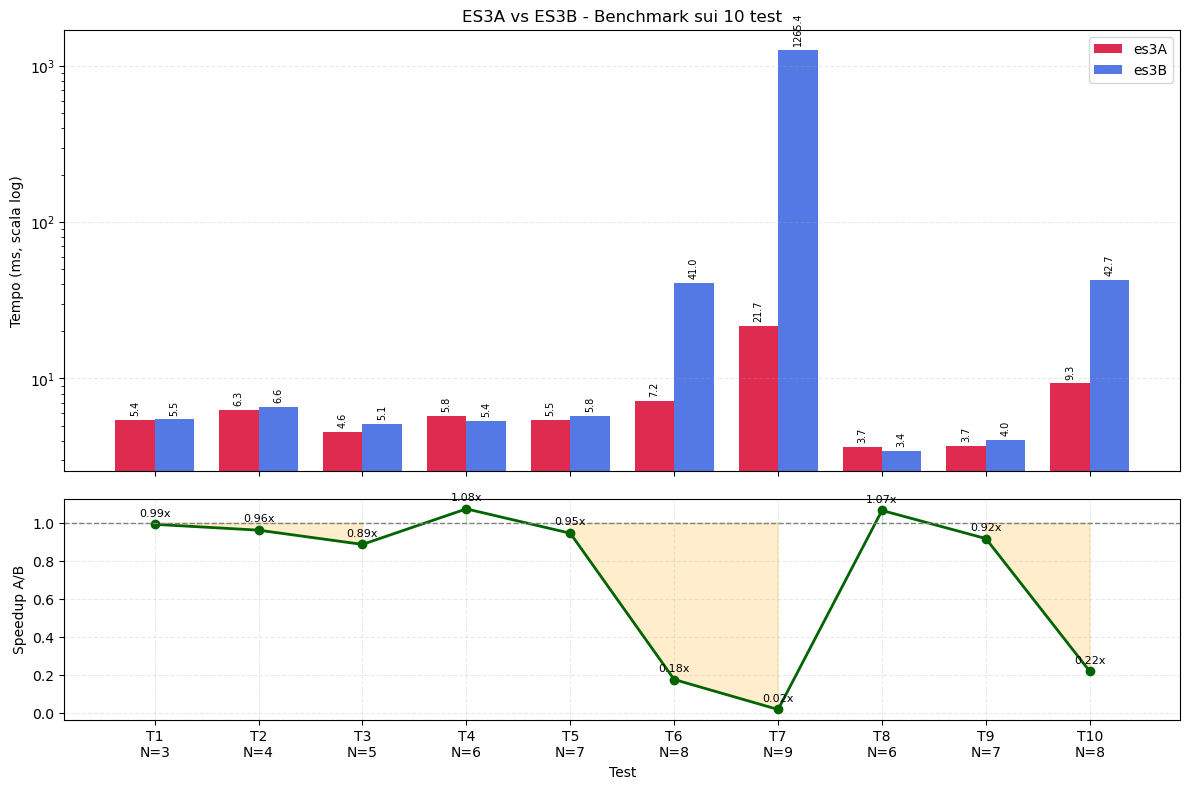

In [43]:
import numpy as np
import matplotlib.pyplot as plt

x = np.arange(len(test_ids))
ta_ms = np.array(times_a) * 1000
tb_ms = np.array(times_b) * 1000
speedup = np.array(times_a) / np.maximum(np.array(times_b), 1e-12)

fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(12, 8), sharex=True, gridspec_kw={"height_ratios": [2, 1]}
)

bar_w = 0.38
bars_a = ax1.bar(x - bar_w / 2, ta_ms, width=bar_w, color="crimson", alpha=0.9, label="es3A")
bars_b = ax1.bar(x + bar_w / 2, tb_ms, width=bar_w, color="royalblue", alpha=0.9, label="es3B")

ax1.set_yscale("log")
ax1.set_ylabel("Tempo (ms, scala log)")
ax1.set_title("ES3A vs ES3B - Benchmark sui 10 test")
ax1.grid(True, axis="y", alpha=0.25, linestyle="--")
ax1.legend()

for rect in list(bars_a) + list(bars_b):
    h = rect.get_height()
    ax1.annotate(
        f"{h:.1f}",
        xy=(rect.get_x() + rect.get_width() / 2, h),
        xytext=(0, 3),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=7,
        rotation=90,
    )

ax2.plot(x, speedup, marker="o", linewidth=2, color="darkgreen")
ax2.axhline(1.0, color="gray", linestyle="--", linewidth=1)
ax2.fill_between(x, speedup, 1.0, where=(speedup >= 1.0), alpha=0.2, color="green")
ax2.fill_between(x, speedup, 1.0, where=(speedup < 1.0), alpha=0.2, color="orange")
ax2.set_ylabel("Speedup A/B")
ax2.set_xlabel("Test")
ax2.grid(True, alpha=0.25, linestyle="--")
ax2.set_xticks(x)
ax2.set_xticklabels(labels)

for xi, sp in zip(x, speedup):
    ax2.annotate(f"{sp:.2f}x", (xi, sp), textcoords="offset points", xytext=(0, 6), ha="center", fontsize=8)

plt.tight_layout()
plt.show()